In [1]:
from dask.distributed import Client
client = Client(threads_per_worker = 1, memory_limit = 0)
client.amm.start()

In [1]:
import os
os.chdir('/g/data/vf71/la6889/lme_scale_calibration_ISMIP3a/scripts/')
from glob import glob
import pandas as pd
import numpy as np
import useful_functions as uf
import xarray as xr
import json

In [2]:
#Base folder where GFDL outputs are 
base_dir = '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/'
# Getting list of FAO regions
fao_lme_code = [f for f in os.listdir(base_dir) if 'fao_lme' in f]
# Using higher resolution inputs only - Non-spatial calibration is done only once
res = '025deg'

In [46]:
# Defining base folder
base_dir = '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/'
# Getting list of FAO regions
fao_lme_code = [f for f in os.listdir(base_dir) if 'fao_lme' in f]

In [47]:
fao_lme_code

['fao_lme-39',
 'fao_lme-49',
 'fao_lme-12',
 'fao_lme-47',
 'fao_lme-24',
 'fao_lme-66',
 'fao_lme-46',
 'fao_lme-54',
 'fao_lme-27',
 'fao_lme-34',
 'fao_lme-121',
 'fao_lme-171',
 'fao_lme-157',
 'fao_lme-13',
 'fao_lme-9',
 'fao_lme-38',
 'fao_lme-181',
 'fao_lme-5',
 'fao_lme-23',
 'fao_lme-59',
 'fao_lme-20',
 'fao_lme-44',
 'fao_lme-63',
 'fao_lme-187',
 'fao_lme-42',
 'fao_lme-65',
 'fao_lme-14',
 'fao_lme-22',
 'fao_lme-56',
 'fao_lme-3',
 'fao_lme-26',
 'fao_lme-31',
 'fao_lme-10',
 'fao_lme-52',
 'fao_lme-64',
 'fao_lme-25',
 'fao_lme-48',
 'fao_lme-32',
 'fao_lme-55',
 'fao_lme-8',
 'fao_lme-50',
 'fao_lme-61',
 'fao_lme-147',
 'fao_lme-134',
 'fao_lme-1',
 'fao_lme-2',
 'fao_lme-127',
 'fao_lme-57',
 'fao_lme-188',
 'fao_lme-43',
 'fao_lme-6',
 'fao_lme-29',
 'fao_lme-141',
 'fao_lme-51',
 'fao_lme-60',
 'fao_lme-158',
 'fao_lme-15',
 'fao_lme-18',
 'fao_lme-37',
 'fao_lme-45',
 'fao_lme-131',
 'fao_lme-19',
 'fao_lme-35',
 'fao_lme-41',
 'fao_lme-151',
 'fao_lme-4',
 'fao

In [3]:
smoothing = None

# Set variables to find correct input files based on 'smoothing' variable - Also
# used to name processed inputs
if smoothing != None:
    smoothing = f'-{smoothing}'
    weighted_fn = '-smoothed'
else:
    smoothing = ''
    weighted_fn = ''

In [4]:
# weights = xr.open_zarr(
#     glob(os.path.join(gridded_folder, '*area*'))[0]).cellareao
# #Areas outside LME need to be given a value of 0
# weights = weights.fillna(0)
aoi = 'fao_lme-1'
region_int = aoi.replace('-', ' ').upper()
exp = 'obsclim'

In [5]:
gridded_folder = os.path.join(base_dir, aoi, f'gridded{smoothing}', res)
gridded_folder

'/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg'

In [6]:
area = xr.open_zarr(
        glob(os.path.join(gridded_folder, '*area*'))[0]).cellareao

In [58]:
area.sum().values.tolist()

1259292519125.2412

In [51]:
area.values.sum()

np.float64(nan)

In [57]:
area.fillna(0).sum().values.tolist()

1259292519125.2412

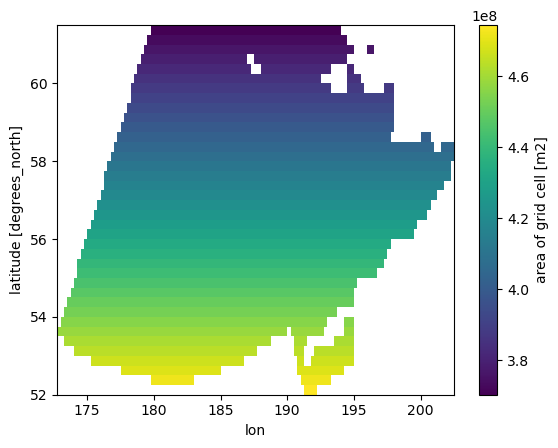

In [60]:
area.plot()

In [7]:
lphy = xr.open_zarr(glob(os.path.join(gridded_folder, f'*{exp}*lphy*'))[0])['lphy']
sphy = xr.open_zarr(glob(os.path.join(gridded_folder, f'*{exp}*sphy*'))[0])['sphy']
weights = ((lphy+sphy)*area).fillna(0)

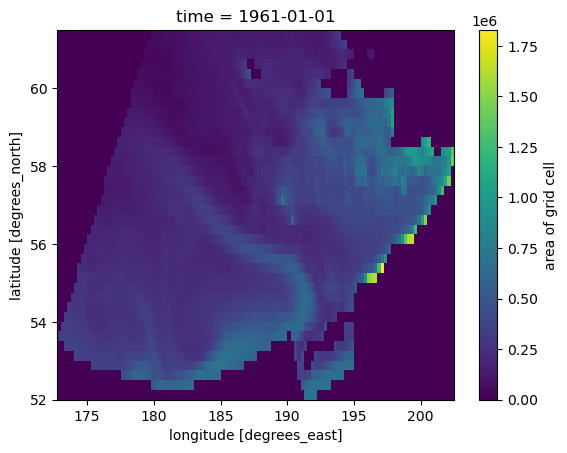

In [63]:
weights.isel(time =0).plot()

In [42]:
lphy.time.dt.year.min().values.tolist()

1961

In [31]:
os.path.join(base_dir, f'{aoi}/monthly_weighted{smoothing}')

'/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/monthly_weighted'

In [32]:
os.path.join(base_dir, aoi, f'monthly_weighted{smoothing}')

'/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/monthly_weighted'

In [8]:
all_fn = glob(os.path.join(gridded_folder, f'gfdl*{exp}*'))
all_fn

['/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_slope_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_deptho_15arcmin_fao_lme-1_fixed.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_intercept_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_tob_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_er_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_simask_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gf

In [9]:
vars_int = ['deptho', 'tob', 'er', 'simask', 'ocean-temp-weighted', 'lphy', 'sphy',
            'expc-bot', 'input-w20m']

In [10]:
test = []
for var in vars_int:
    [res] = [fn for fn in all_fn if f'_{var}_' in fn]
    # if res is not None:
    test.append(res)

In [20]:
da = xr.open_mfdataset(test)
da

/jobfs/173472490.gadi-pbs/ipykernel_1552120/3003868288.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  da = xr.open_mfdataset(test)


<xarray.Dataset> Size: 109MB
Dimensions:              (lat: 38, lon: 119, time: 600)
Coordinates:
  * lat                  (lat) float64 304B 52.12 52.38 52.62 ... 61.12 61.38
  * lon                  (lon) float64 952B 172.9 173.1 173.4 ... 202.1 202.4
  * time                 (time) datetime64[ns] 5kB 1961-01-01 ... 2010-12-01
Data variables:
    deptho               (lat, lon) float32 18kB dask.array<chunksize=(38, 119), meta=np.ndarray>
    tob                  (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    export_ratio         (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    simask               (lat, time, lon) float64 22MB dask.array<chunksize=(38, 600, 119), meta=np.ndarray>
    ocean-temp-weighted  (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    lphy                 (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    sphy                 (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    expc-bot             (time, lat, lon) float32 11MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>
    input_w              (time, lat, lon) float64 22MB dask.array<chunksize=(600, 38, 119), meta=np.ndarray>

In [26]:
glob(os.path.join(gridded_folder, f'*{exp}*deptho*'))

['/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_deptho_15arcmin_fao_lme-1_fixed.zarr']

In [29]:
test_df['depth_m'] = da['deptho'].weighted(area.fillna(0)).mean(('lat', 'lon')).values

In [11]:
test_df = uf.weighted_mean_timestep(test, weights, region_int)

/g/data/vf71/la6889/lme_scale_calibration_ISMIP3a/scripts/useful_functions.py:300: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  da = xr.open_mfdataset(file_paths, engine = 'zarr')


In [30]:
test_df

,region,scenario,time,year,month,depth_m,tot_area_m2,tob,export_ratio,simask,ocean-temp-weighted,lphy,sphy,expc-bot,input_w,intercept,slope
0,FAO_LME 1,obsclim,1961-01-01,1961,January,1776.620769,2.229395e+12,1.273405,0.159073,1.0,2.006919,0.000368,0.000623,6.197729e-09,3.334532,-1.611680,-1.046296
1,FAO_LME 1,obsclim,1961-02-01,1961,February,1776.620769,2.229395e+12,0.774462,0.200359,1.0,1.347539,0.001049,0.001018,1.719669e-08,9.252248,-0.885218,-0.997366
2,FAO_LME 1,obsclim,1961-03-01,1961,March,1776.620769,2.229395e+12,0.594104,0.237972,1.0,1.034762,0.001920,0.000859,3.181873e-08,17.119263,-0.244180,-0.929200
3,FAO_LME 1,obsclim,1961-04-01,1961,April,1776.620769,2.229395e+12,0.550968,0.280575,1.0,0.971759,0.003144,0.000907,6.560496e-08,35.297094,0.184597,-0.890564
4,FAO_LME 1,obsclim,1961-05-01,1961,May,1776.620769,2.229395e+12,1.142938,0.276171,1.0,2.027303,0.004593,0.001469,1.445483e-07,77.770557,0.298537,-0.899685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,FAO_LME 1,obsclim,2010-08-01,2010,August,1776.620769,2.229395e+12,3.406447,0.187321,1.0,7.335374,0.002589,0.001731,9.535627e-08,51.304034,-0.310738,-0.964586
596,FAO_LME 1,obsclim,2010-09-01,2010,September,1776.620769,2.229395e+12,3.853935,0.190051,1.0,7.982363,0.002153,0.001284,7.452741e-08,40.097595,-0.334731,-0.954486
597,FAO_LME 1,obsclim,2010-10-01,2010,October,1776.620769,2.229395e+12,3.500379,0.198063,1.0,6.444877,0.001568,0.000907,4.480150e-08,24.104319,-0.457528,-0.951807
598,FAO_LME 1,obsclim,2010-11-01,2010,November,1776.620769,2.229395e+12,2.699826,0.192688,1.0,4.492704,0.000838,0.000654,2.050827e-08,11.033956,-0.875590,-0.978130


In [45]:
test_df['intercept'], test_df['slope'] = 
uf.GetPPIntSlope(sphy_file = test_df['sphy'].values, lphy_file = test_df['lphy'].values)

SyntaxError: invalid syntax (515654899.py, line 1)

In [16]:
test_df['intercept'] = intercept

In [15]:
slope

array([-1.04629603, -0.99736564, -0.92919957, -0.89056404, -0.89968486,
       -0.97274334, -1.0051419 , -0.96925292, -0.95461925, -0.95836207,
       -0.98124999, -1.01538975, -1.0597784 , -1.02851485, -0.90868634,
       -0.86974462, -0.90288749, -1.00196347, -0.99045948, -0.95803551,
       -0.9525777 , -0.95973039, -0.97489186, -1.01238275, -1.05239745,
       -0.99918595, -0.90943448, -0.89255434, -0.91625867, -0.98207008,
       -0.9949905 , -0.96560562, -0.95058125, -0.96024359, -0.96846297,
       -1.01614811, -1.05611663, -1.03678841, -0.95596239, -0.86931006,
       -0.88829723, -0.95133613, -1.00854762, -0.96659705, -0.95486289,
       -0.95802948, -0.98202833, -1.02052485, -1.05885959, -1.04731862,
       -0.93908978, -0.84437942, -0.89714663, -0.98522217, -1.01008616,
       -0.96621024, -0.95360531, -0.95216747, -0.978578  , -1.02063187,
       -1.06339499, -1.00340089, -0.93548672, -0.88199018, -0.88475177,
       -0.9792453 , -1.01443003, -0.96919456, -0.95402931, -0.96

In [81]:
isinstance(a, np.ndarray)

True

In [78]:
a

array([0.00062254, 0.00101764, 0.00085884, 0.00090697, 0.00146948,
       0.00264345, 0.00262223, 0.0017819 , 0.00129566, 0.00092149,
       0.00064838, 0.00041559, 0.00058553, 0.00094975, 0.00093891,
       0.00084829, 0.00158455, 0.00279965, 0.00230426, 0.00154201,
       0.00126545, 0.00093703, 0.00062453, 0.00043166, 0.00051924,
       0.00110481, 0.00072014, 0.00095874, 0.00145872, 0.00245561,
       0.00247858, 0.00168229, 0.00126455, 0.00093078, 0.00061236,
       0.00044021, 0.00061376, 0.00092197, 0.00090797, 0.00077533,
       0.0013093 , 0.00265827, 0.00275434, 0.00169091, 0.00118563,
       0.00088228, 0.00062412, 0.00043608, 0.00052171, 0.00089043,
       0.00106113, 0.00089556, 0.0013994 , 0.00250873, 0.00259887,
       0.0016303 , 0.00126404, 0.00093786, 0.00061585, 0.00042789,
       0.00061461, 0.00099205, 0.00092812, 0.00088838, 0.00137316,
       0.00255543, 0.00275483, 0.00175009, 0.00130362, 0.00098039,
       0.00057009, 0.00046638, 0.00059266, 0.00094685, 0.00089

In [22]:
[var for var in vars_int]

['deptho',
 'tob',
 'er',
 'simask',
 'ocean-temp-weighted',
 'lphy',
 'sphy',
 'expc-bot',
 'input-w20m']

In [21]:
v = "|".join(vars_int)
glob(os.path.join(gridded_folder, f'gfdl*obsclim_[v]*'))

[]

In [4]:
gridded_folder = '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/'
area = xr.open_zarr(
        glob(os.path.join(gridded_folder, '*area*'))[0]).cellareao
# phyc = xr.open_zarr(
#         glob(os.path.join(gridded_folder, '*area*'))[0]).cellareao

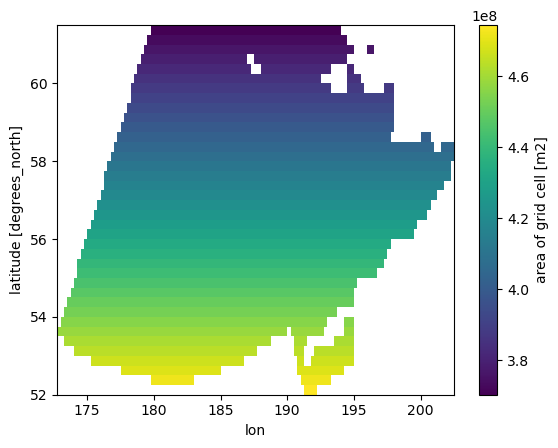

In [6]:
area.plot()

In [39]:
weights = (phyc*area).fillna(0)

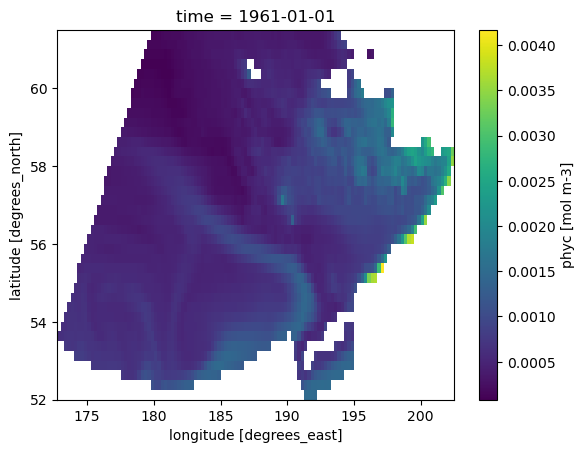

In [37]:
phyc.isel(time = 0).plot()

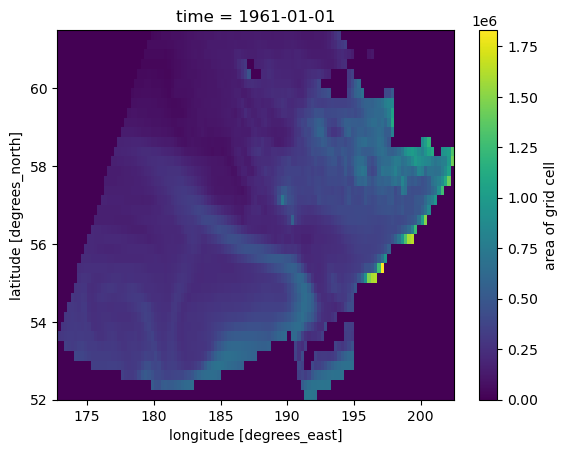

In [40]:
weights.isel(time = 0).plot()

In [41]:
glob(os.path.join(gridded_folder, f'gfdl*obsclim*'))

['/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_slope_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_deptho_15arcmin_fao_lme-1_fixed.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_intercept_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_tob_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_er_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gfdl-mom6-cobalt2_obsclim_simask_15arcmin_fao_lme-1_monthly_1961_2010.zarr',
 '/g/data/vf71/fishmip_inputs/ISIMIP3a/fao_lme_inputs/fao_lme-1/gridded/025deg/gf